# Geovisor - Hospitales y Clinicas ITT

**Proyecto:** Gobierno de Datos 2026

**Repositorio:** [GitHub](https://github.com/j0rg3c45/Hospitales_Cl-nicas_ITT.git)


---
## 1. Dependencias


In [58]:
%pip install folium matplotlib --quiet


---
## 2. Librerias


In [59]:
import json, os
import folium
from folium import FeatureGroup, LayerControl, GeoJson
from folium.plugins import MiniMap, Fullscreen, LocateControl
from IPython.display import display
import matplotlib.pyplot as plt
from collections import Counter
print('Librerias importadas.')


Librerias importadas.


---
## 3. Carga de Datos


In [60]:
# Clonar repo si no existe
if not os.path.exists('Hospitales_Cl-nicas_ITT'):
    !git clone https://github.com/j0rg3c45/Hospitales_Cl-nicas_ITT.git

REPO = 'Hospitales_Cl-nicas_ITT/Data'

# Cargar los 43 centros (del Excel)
with open(f'{REPO}/centros_medicos_completo.json', 'r', encoding='utf-8') as f:
    centros = json.load(f)

# Cargar los 3 puntos de estudio (GeoJSON detallado)
with open(f'{REPO}/hospitales_clinicas.geojson', 'r', encoding='utf-8') as f:
    geojson_puntos = json.load(f)

print(f'Centros (Excel): {len(centros)}')
print(f'Puntos de estudio (GeoJSON): {len(geojson_puntos["features"])}')


Centros (Excel): 43
Puntos de estudio (GeoJSON): 3


---
## 4. Tabla Resumen


In [61]:
header = f"{'#':<3} {'Nombre':<40} {'ESE':<18} {'Comuna':<12} {'Estado':<15} {'Usuarios':>10} {'Monto':>15}"
print(header)
print('-' * len(header))
for i, c in enumerate(centros):
    monto_str = f"${c['monto']:,.0f}" if c['monto'] > 0 else 'Pendiente'
    print(f"{i+1:<3} {c['nombre'][:39]:<40} {c['ese'][:17]:<18} {c['comuna'][:11]:<12} {c['estado'][:14]:<15} {c['usuarios']:>10,} {monto_str:>15}")


#   Nombre                                   ESE                Comuna       Estado            Usuarios           Monto
-----------------------------------------------------------------------------------------------------------------------
1   IPS - UNION DE VIVIENDA POPULAR          ESE Suroriente     COMUNA 16    Finalizado           4,807    $101,550,860
2   IPS - POLVORINES                         ESE Ladera         COMUNA 18    Finalizado           2,851    $490,729,810
3   IPS - PETECUY III                        ESE Norte          COMUNA 06    Finalizado          10,750    $496,980,692
4   IPS - CHARCO AZUL                        ESE Oriente        COMUNA 13    Finalizado           8,300    $706,747,012
5   IPS - CIUDAD CORDOBA                     ESE Oriente        COMUNA 15    Finalizado           7,000    $705,590,738
6   IPS - FRAY DAMIAN                        ESE Ladera         COMUNA 03    Finalizado          11,089    $184,239,319
7   IPS - POPULAR                       

---
## 5. Analisis Grafico


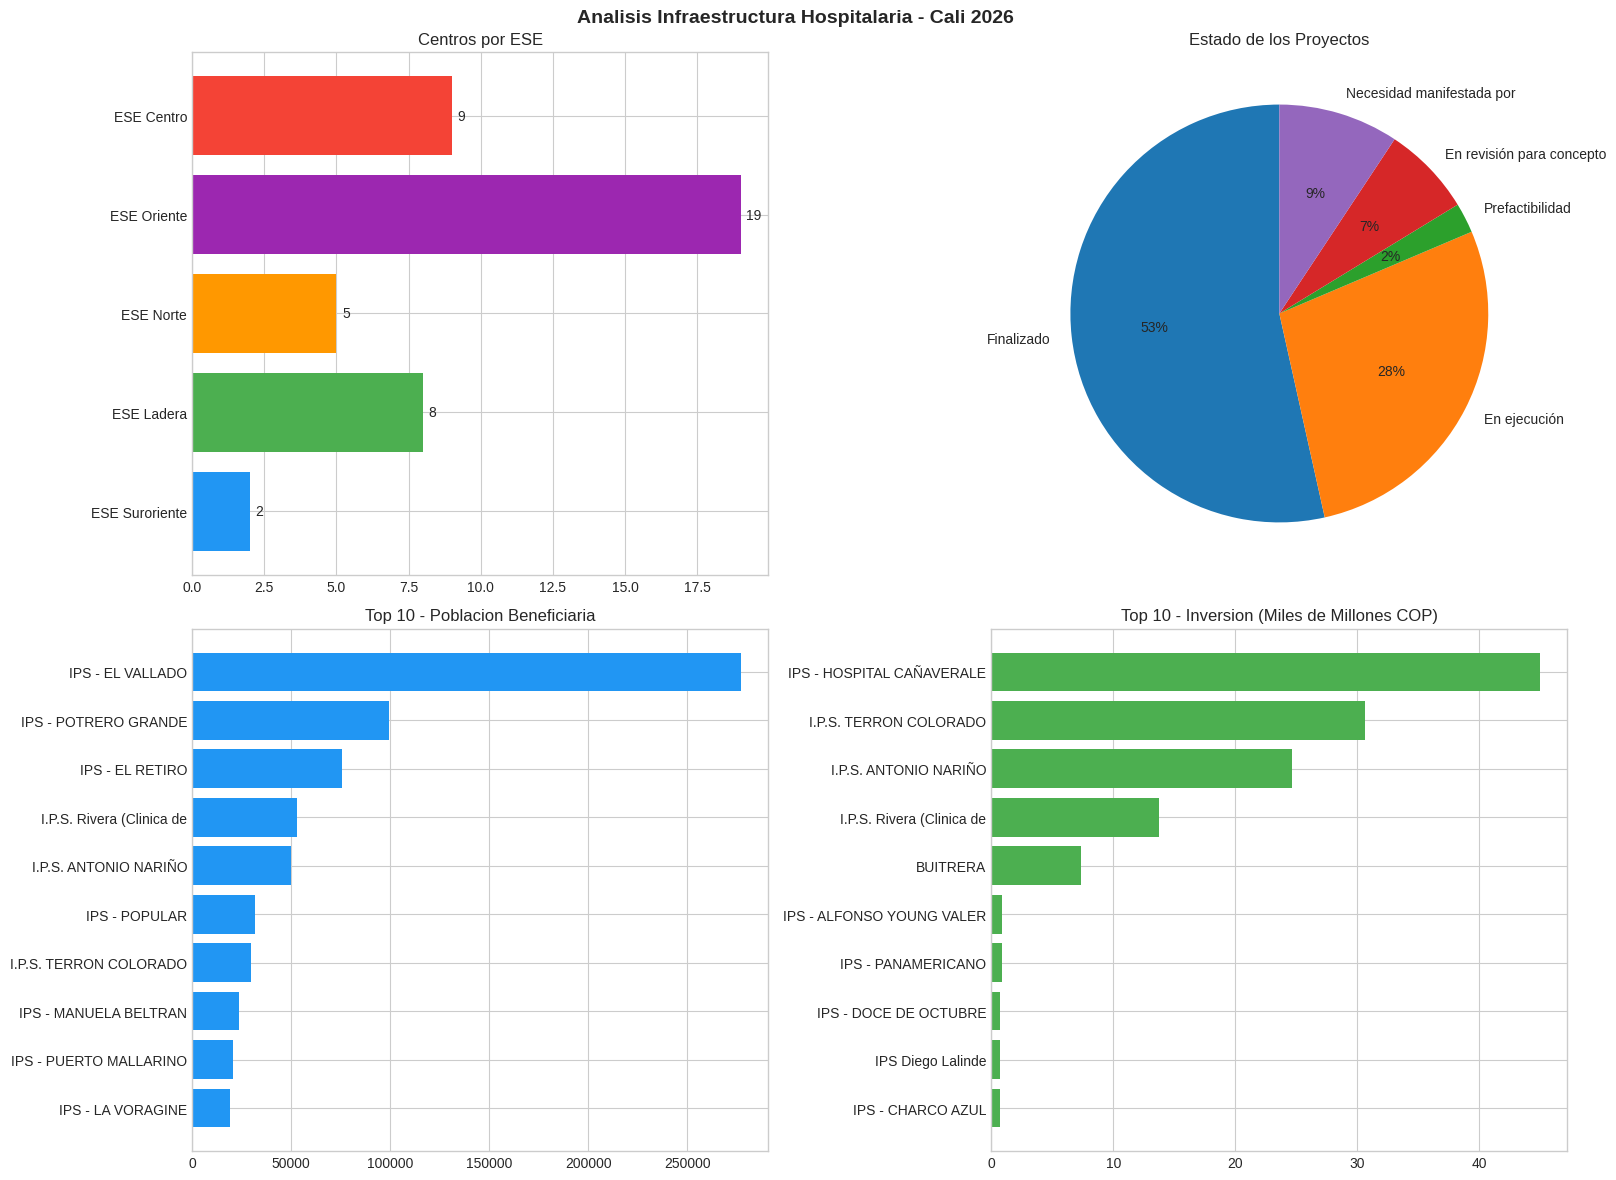

In [62]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Infraestructura Hospitalaria - Cali 2026', fontsize=14, fontweight='bold')

eses = Counter(c['ese'] for c in centros)
ax1 = axes[0, 0]
bars = ax1.barh(list(eses.keys()), list(eses.values()), color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'])
ax1.set_title('Centros por ESE')
for bar in bars:
    ax1.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{int(bar.get_width())}', va='center')

estados = Counter(c['estado'] for c in centros)
ax2 = axes[0, 1]
ax2.pie(estados.values(), labels=[k[:25] for k in estados.keys()], autopct='%1.0f%%', startangle=90)
ax2.set_title('Estado de los Proyectos')

top_u = sorted(centros, key=lambda x: x['usuarios'], reverse=True)[:10]
ax3 = axes[1, 0]
ax3.barh([c['nombre'][:25] for c in top_u][::-1], [c['usuarios'] for c in top_u][::-1], color='#2196F3')
ax3.set_title('Top 10 - Poblacion Beneficiaria')

top_m = sorted([c for c in centros if c['monto']>0], key=lambda x: x['monto'], reverse=True)[:10]
ax4 = axes[1, 1]
ax4.barh([c['nombre'][:25] for c in top_m][::-1], [c['monto']/1e9 for c in top_m][::-1], color='#4CAF50')
ax4.set_title('Top 10 - Inversion (Miles de Millones COP)')

plt.tight_layout()
plt.show()


In [63]:
total_u = sum(c['usuarios'] for c in centros)
total_i = sum(c['monto'] for c in centros if c['monto']>0)
fin = sum(1 for c in centros if c['estado']=='Finalizado')
ej = sum(1 for c in centros if 'ejecuci' in c['estado'].lower())
print('RESUMEN')
print('='*50)
print(f'Total centros:     {len(centros)}')
print(f'Finalizados:       {fin}')
print(f'En ejecucion:      {ej}')
print(f'Otros:             {len(centros)-fin-ej}')
print(f'Poblacion:         {total_u:,}')
print(f'Inversion total:   ${total_i:,.0f}')


RESUMEN
Total centros:     43
Finalizados:       23
En ejecucion:      12
Otros:             8
Poblacion:         954,145
Inversion total:   $140,653,837,895


---
## 6. Espacializacion / Geovisor

- Verde = Finalizado | Naranja = En ejecucion | Azul = En revision | Rojo = Pendiente
- **Morado (estrella) = 3 Puntos de estudio** (del GeoJSON hospitales_clinicas.geojson)
- **Poligonos rojos = Terrenos** (del GeoJSON 2hospitales_clinicas_poligonos)


In [64]:
# --- POLIGONOS convertidos a EPSG:4326 ---
poligonos_4326 = [
    {'nombre': 'Terreno La Rivera - Comuna 05',
     'coords': [[3.4740086,-76.4902269],[3.4738546,-76.4907211],[3.4751942,-76.4911306],
       [3.4754007,-76.4902942],[3.4754079,-76.4902657],[3.4754107,-76.4902446],
       [3.4754059,-76.4902093],[3.4753945,-76.4901825],[3.4753789,-76.4901621],
       [3.4753648,-76.4901466],[3.4753463,-76.490128],[3.4753252,-76.4901113],
       [3.4752917,-76.4900927],[3.4752423,-76.4900744],[3.4751737,-76.4900498],
       [3.4750354,-76.4900015],[3.4746139,-76.4898702],[3.4741893,-76.489738],
       [3.474179,-76.4897356],[3.4741701,-76.4897351],[3.4741618,-76.489738],
       [3.4741568,-76.4897475],[3.474153,-76.4897619],[3.4741441,-76.489792],
       [3.4740086,-76.4902269]]},
    {'nombre': 'Terreno Antonio Narino - Comuna 16',
     'coords': [[3.4165601,-76.5092721],[3.4171388,-76.5086692],
       [3.4158096,-76.5074186],[3.415249,-76.5080124],[3.4165601,-76.5092721]]}
]

# Centro del mapa: promedio de los 3 puntos de estudio del GeoJSON
feats = geojson_puntos['features']
lats_e = [f['geometry']['coordinates'][1] for f in feats]
lons_e = [f['geometry']['coordinates'][0] for f in feats]
center_lat = sum(lats_e) / len(lats_e)
center_lon = sum(lons_e) / len(lons_e)

# Tiles
GSAT = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
GHYB = 'https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}'
GMAP = 'https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}'

mapa = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None, control_scale=True)
folium.TileLayer(tiles=GSAT, attr='Google', name='Google Satellite', overlay=False).add_to(mapa)
folium.TileLayer(tiles=GHYB, attr='Google', name='Google Hybrid', overlay=False).add_to(mapa)
folium.TileLayer(tiles=GMAP, attr='Google', name='Google Maps', overlay=False).add_to(mapa)
folium.TileLayer(tiles='OpenStreetMap', name='OpenStreetMap', overlay=False).add_to(mapa)

def color_estado(estado):
    if estado == 'Finalizado': return 'green'
    elif 'ejecuci' in estado.lower(): return 'orange'
    elif 'revision' in estado.lower() or 'alistamiento' in estado.lower(): return 'blue'
    return 'red'

# === CAPA 1: Todos los centros del Excel (agrupados por ESE) ===
eses_unicas = sorted(set(c['ese'] for c in centros))
for ese in eses_unicas:
    fg = FeatureGroup(name=ese, show=True)
    for c in [x for x in centros if x['ese'] == ese]:
        color = color_estado(c['estado'])
        monto_str = f"${c['monto']:,.0f}" if c['monto']>0 else 'Pendiente'
        popup = (f"<div style='font-family:Arial;font-size:11px;min-width:250px;max-height:300px;overflow-y:auto;'>"
                 f"<b>{c['nombre']}</b><hr>"
                 f"<b>ESE:</b> {c['ese']}<br><b>Tipo:</b> {c['tipo_ips']}<br>"
                 f"<b>Dir:</b> {c['direccion']}<br><b>Comuna:</b> {c['comuna']}<br>"
                 f"<b>Usuarios:</b> {c['usuarios']:,}<br>"
                 f"<b>Amb. actuales:</b> {c['ambientes_actuales']}<br>"
                 f"<b>Amb. proyectados:</b> {c['ambientes_proyectados']}<br>"
                 f"<b>Servicios:</b> {c['servicios_actuales']}<br>"
                 f"<b>Nuevos:</b> {c['servicios_nuevos']}<br>"
                 f"<b>Estado:</b> {c['estado']}<br><b>Monto:</b> {monto_str}</div>")
        folium.Marker(
            location=[c['lat'], c['lon']],
            popup=folium.Popup(popup, max_width=320),
            tooltip=f"{c['nombre']} ({c['estado']})",
            icon=folium.Icon(color=color, icon='plus-sign', prefix='glyphicon')
        ).add_to(fg)
    fg.add_to(mapa)

# === CAPA 2: 3 Puntos de estudio (del GeoJSON hospitales_clinicas.geojson) ===
fg_estudio = FeatureGroup(name='PUNTOS DE ESTUDIO (GeoJSON)', show=True)
for feat in geojson_puntos['features']:
    props = feat['properties']
    coords = feat['geometry']['coordinates']
    lat, lon = coords[1], coords[0]
    nombre = props.get('nombre', 'Sin nombre')

    # Popup con toda la info del GeoJSON
    popup_lines = [f"<div style='font-family:Arial;font-size:11px;min-width:280px;max-height:400px;overflow-y:auto;'>"]
    popup_lines.append(f"<h4 style='color:#6A1B9A;margin-bottom:5px;'>{nombre}</h4><hr>")
    for k, v in props.items():
        if k == 'nombre' or k == 'servicios' or k == 'consulta_externa' or k == 'apoyo_diagnostico' or k == 'terapias_especializadas' or k == 'cobertura_servicios':
            continue
        popup_lines.append(f"<b>{k}:</b> {v}<br>")
    # Servicios si existen
    if 'servicios' in props:
        popup_lines.append('<hr><b>Servicios (actual/proyectada):</b><br>')
        for s in props['servicios']:
            popup_lines.append(f"  {s['nombre']}: {s['actual']}/{s['proyectada']}<br>")
    if 'consulta_externa' in props:
        popup_lines.append('<hr><b>Consulta Externa:</b><br>')
        for s in props['consulta_externa']:
            popup_lines.append(f"  {s['servicio']}: {s.get("consultorios", s.get("unidades", s.get("ambientes", "")))}<br>")
    if 'terapias_especializadas' in props:
        popup_lines.append('<hr><b>Terapias:</b><br>')
        for t in props['terapias_especializadas']:
            popup_lines.append(f"  - {t}<br>")
    popup_lines.append('</div>')
    popup_html = ''.join(popup_lines)

    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=380),
        tooltip=f'[ESTUDIO] {nombre}',
        icon=folium.Icon(color='purple', icon='star', prefix='glyphicon')
    ).add_to(fg_estudio)
fg_estudio.add_to(mapa)

# === CAPA 3: Poligonos de terrenos ===
fg_poly = FeatureGroup(name='TERRENOS (Poligonos)', show=True)
for poly in poligonos_4326:
    geojson_coords = [[c[1], c[0]] for c in poly['coords']]
    feat = {'type':'Feature','properties':{'nombre':poly['nombre']},'geometry':{'type':'Polygon','coordinates':[geojson_coords]}}
    GeoJson(feat, style_function=lambda x: {'color':'red','weight':2,'fillOpacity':0}, tooltip=poly['nombre']).add_to(fg_poly)
fg_poly.add_to(mapa)

# Controles
LayerControl(collapsed=False, position='topright').add_to(mapa)
MiniMap(toggle_display=True, position='bottomleft').add_to(mapa)
Fullscreen(position='topleft').add_to(mapa)
LocateControl(strings={'title':'Mi ubicacion'}).add_to(mapa)

print(f'Geovisor: {len(centros)} centros + 3 puntos de estudio + {len(poligonos_4326)} terrenos.')
print(f'Centro: [{center_lat:.4f}, {center_lon:.4f}]')


Geovisor: 43 centros + 3 puntos de estudio + 2 terrenos.
Centro: [3.4476, -76.5193]


---
## 7. Visualizacion del Geovisor


In [65]:
display(mapa)


---
## 8. Exportacion


In [66]:
OUTPUT = 'geovisor_hospitales_clinicas_ITT.html'
mapa.save(OUTPUT)
print(f'Exportado: {OUTPUT}')
try:
    from google.colab import files
    files.download(OUTPUT)
except:
    print('Abra el archivo desde el explorador.')


Exportado: geovisor_hospitales_clinicas_ITT.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>